# IMT 573 - Final Examination


Points: 100

Name: Varsha Srivastava

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Varsha Srivastava

11.30.2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [38]:
# To supress warnings
import warnings
warnings.filterwarnings("ignore")

# function to create labeled barplots
def labeled_barplot(data, feature, title=None, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: column
    title: title
    n: displays the top n category levels (default is None, i.e., display all levels)
    """
    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    if title is None:
        title = 'Distribution of {}'.format(feature)

    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values()
    )

    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
            
    for p in ax.patches:
        count = p.get_height()            
        label = "{:.0f} ({:.1f}%)".format(count, 100 * count / total)
            
        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=9,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()  # show the plot


### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [39]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [40]:
affairs.describe().T

,count,mean,std,min,25%,50%,75%,max
rate_marriage,6366.0,4.109645,0.961430,1.0,4.0,4.0,5.000000,5.000000
age,6366.0,29.082862,6.847882,17.5,22.0,27.0,32.000000,42.000000
yrs_married,6366.0,9.009425,7.280120,0.5,2.5,6.0,16.500000,23.000000
children,6366.0,1.396874,1.433471,0.0,0.0,1.0,2.000000,5.500000
religious,6366.0,2.426170,0.878369,1.0,2.0,2.0,3.000000,4.000000
educ,6366.0,14.209865,2.178003,9.0,12.0,14.0,16.000000,20.000000
occupation,6366.0,3.424128,0.942399,1.0,3.0,3.0,4.000000,6.000000
occupation_husb,6366.0,3.850141,1.346435,1.0,3.0,4.0,5.000000,6.000000
affairs,6366.0,0.705374,2.203374,0.0,0.0,0.0,0.484848,57.599991


#### Summary Observations:
* The `affairs` dataset contains **6366** participants
* The data set has **9 variables** collected for the participants of the survey
* The variables `rate_marriage`, `religious`, `educ`, `occupation`, `occupation_husb` seems to be categorical in nature
* Variable: `yrs_married` - Mean length of years married is **9 years**. The range is from 0.5 to 23 years
* Variable: `affairs` - Average time spent in extra marital affairs - **0.7 years** with minimum of 0 years and maximum of 57.6 years
#### Observations on `age` and `children`:
* Variable: `age` - Mean age of the participants is **29.08 years**. The participants range from 17 to 42 years
* Variable: `children` - Average number of children per participant is **1.39**. The range is 0 to 5.5

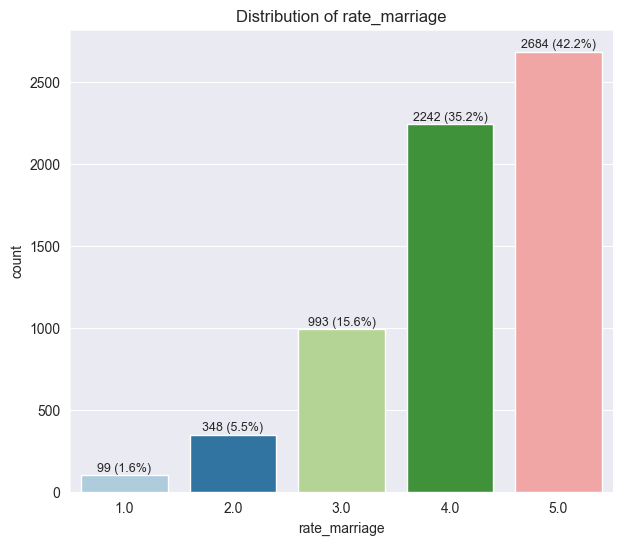

In [41]:
labeled_barplot(data=affairs, feature='rate_marriage')

#### Observation on variable: `rate_marriage`
* Approx - 42.2% of the participants have rated their marriage as `very good`
* Approx - 35.2% of the participants have rated their marriage as `good`
* Small percentage of the participants have rated their marriage as `very poor` (approx. 1.6%) and `poor` (approx - 5.5%)
* Mean value is ~ 4.1, suggesting that the participants are generally rated their marraige as good. 

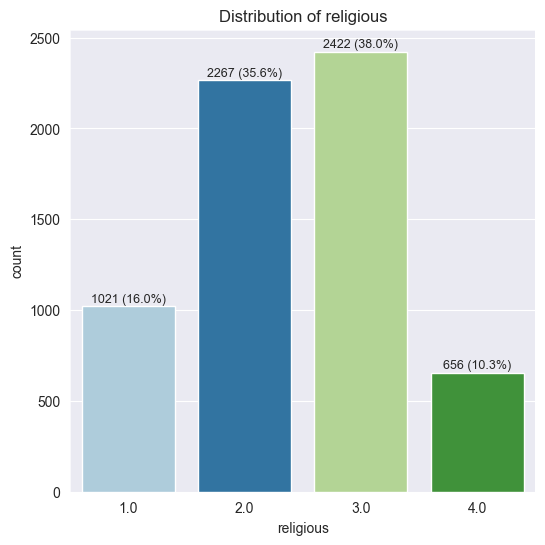

In [42]:
labeled_barplot(data=affairs, feature='religious')

#### Observation on variable: `religious`
* Approx - 38.0% of the participants are `fairly` religious
* Approx - 35.6% of the participants are `midly` religious
* Mean Value is  ~2.4, suggesting that participants are mildly reglious


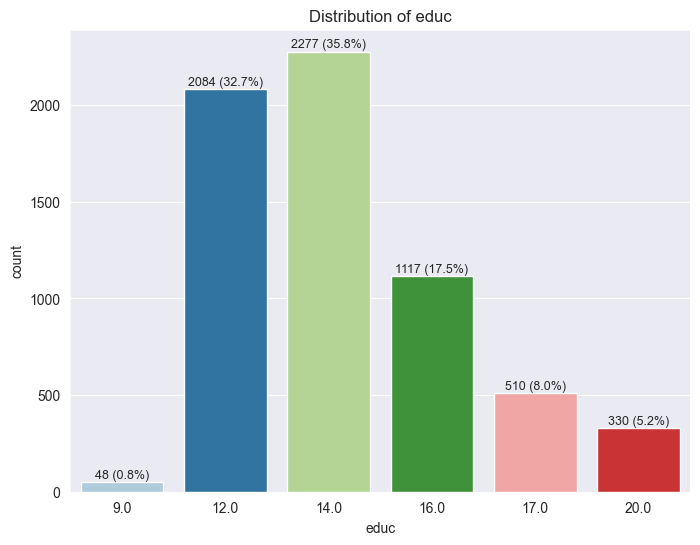

In [43]:
labeled_barplot(data=affairs, feature='educ')

#### Observation on variable: `educ`
* Approx - 35.8% of the participants have some college education
* Approx - 32.7% of the participants have at least high school education
* Mean value is ~14.2 which suggest that participants are moderately educate with some college education

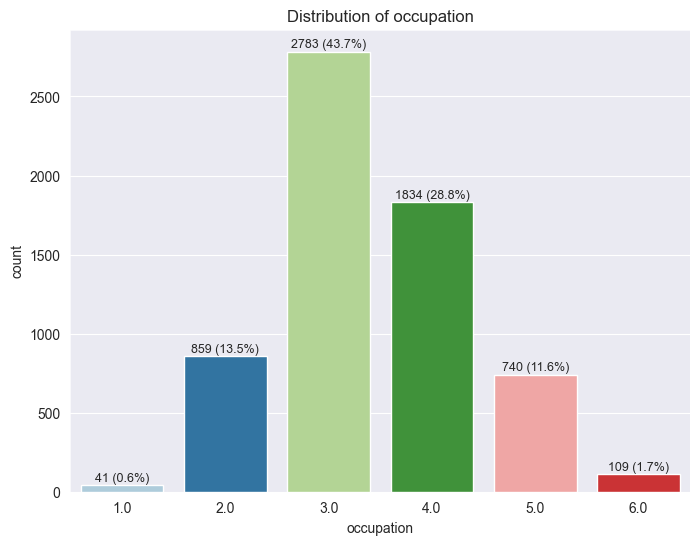

In [44]:
labeled_barplot(data=affairs, feature='occupation')

#### Observation on variable: `occupation`
* Approx - 43.7% of the participants have white collar job
* Approx - 28.8% of the participants are in skilled profession such as teacher,counselor,social worker, nurse; artist, writers,                   technician or skilled worker
* Small percentage of the participants are students (0.6%) and professional with advance degree (1.7%)

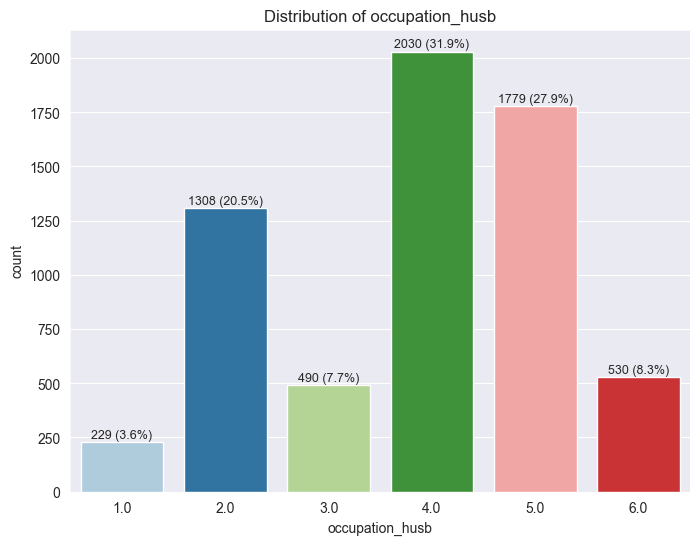

In [45]:
labeled_barplot(data=affairs, feature='occupation_husb')

#### Observation on variable: `occupation_husb`
* Approx - 31.9% of the participants are in skilled profession such as teacher,counselor,social worker, nurse; artist, writers; technician or skilled worker
* Approx - 27.9% of the participants are in managerial profession
* Approx - 20.5% of the participants are in  farming, agriculture; semi-skilled, or unskilled worker


#### Ethical and Privacy Concerns
Although the Fair's Affairs is widely used for education and research purposes, it does bring ethical and privacy concerns as mentioned -
* Provides sensitive personal information related to marital satisfaction, extra marital affairs and demographics about the population sample
* The data represent societal norms during 1969 with a small sample set. This cannot be used to draw analogy with modern structure as it will lead to misinterpretation and generalization as the current societal structure is different.
* The data collected from participants may not have the modern standards of informed consent on data usage such as online sharing, transparency and  global availability using `statsmodels` libraries

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

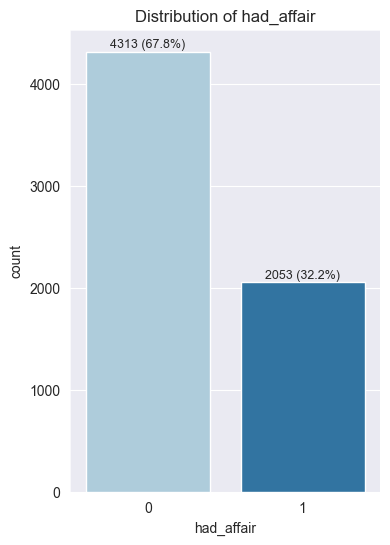

In [46]:
affairs['had_affair'] = (affairs['affairs'] > 0).astype(int)

labeled_barplot(data=affairs, feature='had_affair')

#### Observation
* **~ 67.8%** of participants had no extra marital affairs whereas **~32.2%** were involved in extra marital affairs
* **Advantages of this approach**
  * Simplifies the problem with binary outcomes of 0 being no extra marital affair and 1 being involved in extra marital affair
  * Removes outlier with participants having length of affair as high as 57.5 years
* **Disadvantages of this approach**
  * Loss of information as binary approach cannot quantify some of the relationship such as impact on martial satisfaction along with length of affair, possible relationship with other details such profession, education level, religiousness and other family dynamics on affairs
  * It also oversimplifies human behavior with binary classification



(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [47]:
import statsmodels.api as sm
import statsmodels.formula.api as smf


full_model = smf.logit("had_affair ~ age + yrs_married + children + religious + educ + occupation + occupation_husb + rate_marriage ", data=affairs).fit()
print(full_model.summary())
print('\n **** Model AIC - {}'.format(full_model.aic))

Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1327
Time:                        08:10:21   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           3.7257      0.299     12.470      0.000       3.140       4.311
age           

#### Observations
These are statistically significant predictors ( p < 0.05) which can used to determine having affair or not having affair -
* age
* yrs_married
* religious
* occupation
* rate_marriage
* educ

These are not statistically significant predictors
* children
* occupation_husb


(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

#### Stepwise selection procedure
  * Variables having p-value greater than 0.05 are not considered as not statistically significant and can be dropped from the variable list to be used for predictive model. In our dataset, we have these variables which can be dropped -
    * `children` with p-value = 0.893
    * `occupation_husb` with p-value = 0.589
  * Variables having p-value less than 0.05 are considered statistically significant and will be used for predictive model. Here are the variables
    * age
    * yrs_married
    * religious
    * occupation
    * rate_marriage
    * educ


In [48]:
best_model = smf.logit("had_affair ~ age + yrs_married + religious + educ + occupation + rate_marriage ", data=affairs).fit()
print(best_model.summary())
print('\n **** Model AIC - {}'.format(best_model.aic))

Optimization terminated successfully.
         Current function value: 0.545339
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1326
Time:                        08:10:21   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.7371      0.296     12.622      0.000       3.157       4.317
age              -0.

#### Observation
The AIC value for best fit model shows lower number **~6957.25** which means it is better performing than the full model. The best fit model is slightly different from full model. Here are the details of variables in the final model -

* Selected - `age` `yrs_married` `religious` `educ` `occupation` `rate_marriage`
* Not Selected - `children` `occupation_husb`



(e) Interpret the model parameters using the model from part (d).

#### Interpretation of the parameters


|**Variable**|**Coeff**|**Effect**|**Interpretation**|
|------------|---|---|---------|
|age|-0.06|Slightly Negative|Older participants are less likely to have an extra marital affair|
|yrs_married|0.109|Positive|Participants with longer marriage have increased chance of having an extra marital affair|
|religious|-0.376|Negative|More religious participants are less likely to have an extra marital affair|
|educ|-0.038|Slightly Negative|More educated participants have slightly less chance to have an extra marital affair|
|occupation|0.162|Positive|Participants with lower skilled profession are more likely to have an extra marital affair|
|rate_marriage|-0.715|Slightly Negative|Higher marital satisfaction reduces chances to have an extra marital affair|

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

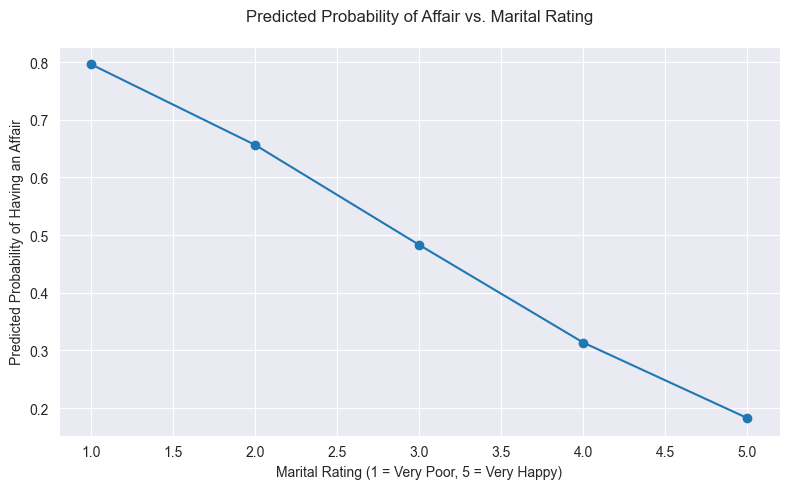

In [49]:
# Creating an artificial data set with approx 10% of the original dataset
np.random.seed(42)

test = pd.DataFrame({
    "rate_marriage": np.random.randint(1, 6, 630),
    "age": affairs["age"].mean(),
    "yrs_married": affairs["yrs_married"].mean(),
    "religious": affairs["religious"].mean(),
    "educ": affairs["educ"].mean(),
    "occupation": affairs["occupation"].mean()
})

# Calculating predicted probability based on best-fit model
test["predicted_prob"] = best_model.predict(test)

# Summarizing the predicted probability by rate_marriage
prob_by_rating = (
    test.groupby("rate_marriage")["predicted_prob"]
        .mean()
        .reset_index()
        .sort_values("rate_marriage")
)

# Generating the plot for predicted probability by rate_marriage
plt.figure(figsize=(8, 5))
plt.plot(
    prob_by_rating["rate_marriage"],
    prob_by_rating["predicted_prob"],
    marker="o"
)

plt.xlabel("Marital Rating (1 = Very Poor, 5 = Very Happy)")
plt.ylabel("Predicted Probability of Having an Affair")
plt.title("Predicted Probability of Affair vs. Marital Rating\n")
#plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretation of the results

The above visualization on predicted probabilities of having affairs and marital rating shows decline slope which indicated that likelihood of having an affair reduces as marital happiness improves given all other variables such as `age`, `educ`, `occupation`, `religious` and `yrs_married` are  constant at their means. Marital satisfaction alone seems to be the most influential variable in predicting extra-marital affairs.



(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

#### Summary Analysis
In addition to the earlier concerns raised on ethical and privacy concerns, here are some additional concerns that I would like to highlight -
1. Predication using the above data about sensitive human behaviour poses risk of mis-interpretation and misuse of statistical results as extra-marital affair is sensitive issue and can have damaging effect on personal lives
2. The correlation effect across variables in the best fit model cannot be considered as causation as this could lead to overgeneralized and making biased claims on human behaviour
3. It is specific study done in 1969 and cannot be used as a model for current societal norms.


### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [50]:
pip install ISLP


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [51]:

from ISLP import load_data
Hitters = load_data('Hitters')

print("\n Sample Data:")
print(Hitters.head())

print("\n Dataset Info:")
print(Hitters.info())

print("\n Dataset Shape:")
print(Hitters.shape)



 Sample Data:
   AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  CHits  CHmRun  CRuns  \
0    293    66      1    30   29     14      1     293     66       1     30   
1    315    81      7    24   38     39     14    3449    835      69    321   
2    479   130     18    66   72     76      3    1624    457      63    224   
3    496   141     20    65   78     37     11    5628   1575     225    828   
4    321    87     10    39   42     30      2     396    101      12     48   

   CRBI  CWalks League Division  PutOuts  Assists  Errors  Salary NewLeague  
0    29      14      A        E      446       33      20     NaN         A  
1   414     375      N        W      632       43      10   475.0         N  
2   266     263      A        W      880       82      14   480.0         A  
3   838     354      N        E      200       11       3   500.0         N  
4    46      33      N        E      805       40       4    91.5         N  

 Dataset Info:
<class 'pandas.core.

(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

 #### Question
 This is question that I would like to address with my analysis:
 * Does years of experience (years) has impact on salary prediction of a player?

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [52]:
print(Hitters.describe().T)

         count         mean          std   min     25%     50%      75%  \
AtBat    322.0   380.928571   153.404981  16.0  255.25   379.5   512.00   
Hits     322.0   101.024845    46.454741   1.0   64.00    96.0   137.00   
HmRun    322.0    10.770186     8.709037   0.0    4.00     8.0    16.00   
Runs     322.0    50.909938    26.024095   0.0   30.25    48.0    69.00   
RBI      322.0    48.027950    26.166895   0.0   28.00    44.0    64.75   
Walks    322.0    38.742236    21.639327   0.0   22.00    35.0    53.00   
Years    322.0     7.444099     4.926087   1.0    4.00     6.0    11.00   
CAtBat   322.0  2648.683230  2324.205870  19.0  816.75  1928.0  3924.25   
CHits    322.0   717.571429   654.472627   4.0  209.00   508.0  1059.25   
CHmRun   322.0    69.490683    86.266061   0.0   14.00    37.5    90.00   
CRuns    322.0   358.795031   334.105886   1.0  100.25   247.0   526.25   
CRBI     322.0   330.118012   333.219617   0.0   88.75   220.5   426.25   
CWalks   322.0   260.2391

#### Interpretations
* Total rows 322 and variables are 20
* There are 3 categorical data - `League` `Division` `New League` and rest 17 variables are numeric
* Salary ranges are highly variable - 67.5 to 2460
* Years of experience ranges from 1 to 24 years


(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

In [53]:
## Data cleaning
Hitters_clean = Hitters.dropna(subset=['Salary']).copy()

# Fitting Simple Linear regresion Model
y = Hitters_clean['Salary']
X_reduced = Hitters_clean[['Years']] 
X_reduced = sm.add_constant(X_reduced)

model_reduced = sm.OLS(y, X_reduced).fit()
print("\nSimple Linear Regression (Reduced):")
print(model_reduced.summary())



Simple Linear Regression (Reduced):
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     49.91
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           1.46e-11
Time:                        08:10:21   Log-Likelihood:                -1957.1
No. Observations:                 263   AIC:                             3918.
Df Residuals:                     261   BIC:                             3925.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        26

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [54]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [55]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

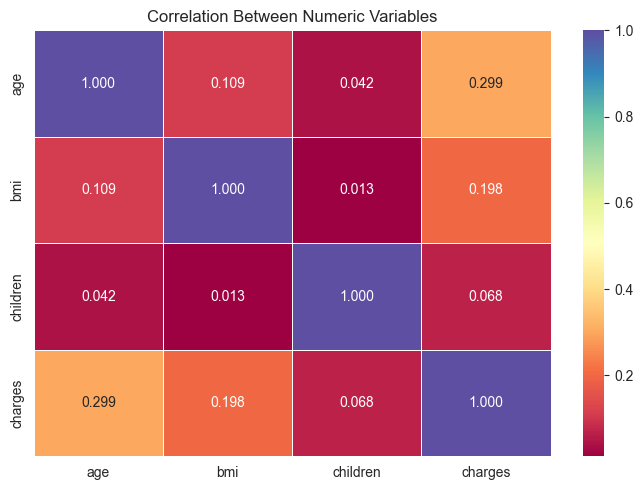

In [56]:
# Bivariate relationship with numeric variables
num_variables = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_variables].corr(), annot=True, fmt=".3f", linewidths=0.5, cmap="Spectral")
plt.title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.show()

#### Relationship between numeric variables -

|**Variable Pair**|**Correlation**|**Interpretation**|
|------------|---|-----------|
|age & charges|0.299|Moderate positive relationship which means older beneficiaries tends to have higher medical costs|
|bmi & charges|0.198|Moderate positive relationship which means beneficiaries with higher BMI have higher medical costs|
|children & charges|0.068|Weak positive relationship which means number of children does not strongly predict higher medical costs|

* **Summary:**
  * `age` and `bmi` are string predictors for `charges`

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generic function to plot averages against features
def averages_barplot(data, feature):
    ax = sns.barplot(data=data, x=feature, y="charges", estimator="mean", ci=None,  palette="Paired")
    
    ax.set_title("Average Charges by {}".format(feature))
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
                
    for p in ax.patches:
        count = p.get_height()
        label = "${:.0f}".format(count)
            
        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height() + 1 # height of the plot
    
        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=9,
            xytext=(0, 4),
            textcoords="offset points",
        )  # annotate the percentage
    
    plt.ylabel("Average Charges")
    plt.xlabel(feature)
    plt.tight_layout()



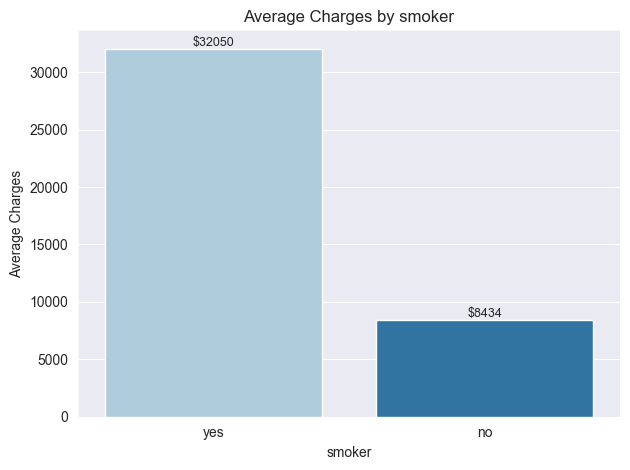

In [58]:
averages_barplot(df, 'smoker')

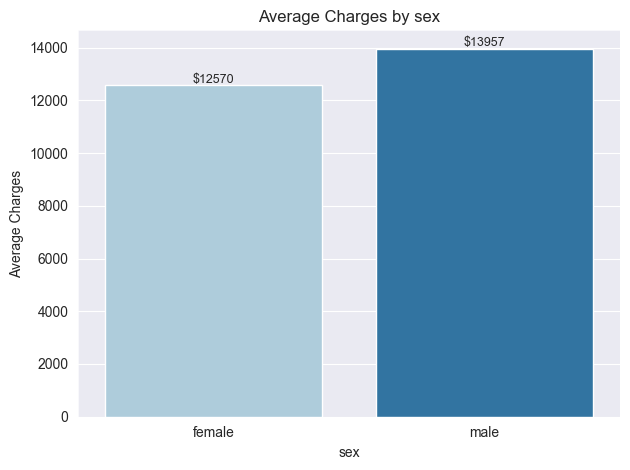

In [59]:
averages_barplot(df, 'sex')

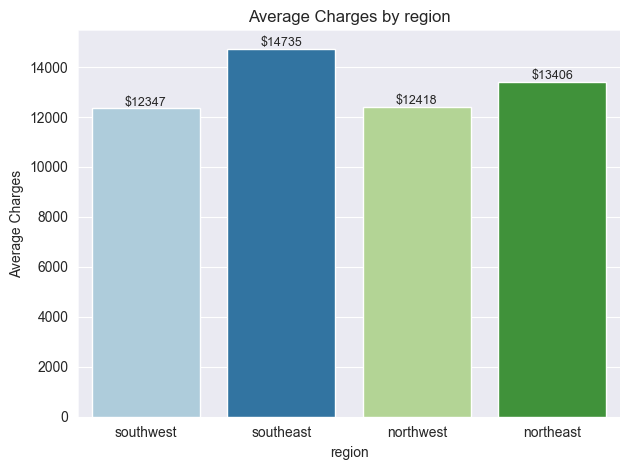

In [60]:
averages_barplot(df, 'region')

#### Relationship charges between category variables -
* Average charge differences between smokers - `$32050` and non-somkers - `$8434` is 4x times.
* Average charge differences between male - `$13957` and female - `$12570` is relatively small.
* Average charge differences between different regions are marginal with southeast region having the highest cost.


(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [61]:
import statsmodels.api as sm

# Encoding categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

for cols in ['sex_male','smoker_yes','region_northwest','region_southeast', 'region_southwest']:
    df_encoded[cols] =  df_encoded[cols].astype(int)

# Full model (with BMI)
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X_full = sm.add_constant(X)
full_model = sm.OLS(y, X_full).fit()

# Reduced model (remove BMI)
X_reduced =df_encoded.drop(columns=['charges', 'bmi'])
X_reduced = sm.add_constant(X_reduced)
reduced_model = sm.OLS(y, X_reduced).fit()

# R-saured values
full_r2 = full_model.rsquared
reduced_r2 = reduced_model.rsquared
partial_r2 = (full_model.rsquared - reduced_model.rsquared) / (1 - reduced_model.rsquared)

results_df = pd.DataFrame({
    'Metric': ['R-squared for Full Model (with bmi)', 'R-squared for Reduced Model (without bmi)', 'Partial R-squared for bmi'],
    'Value': [full_r2, reduced_r2, partial_r2]
})

print("\nR-squared Summary:\n", results_df)




R-squared Summary:
                                       Metric     Value
0        R-squared for Full Model (with bmi)  0.750913
1  R-squared for Reduced Model (without bmi)  0.724549
2                  Partial R-squared for bmi  0.095711


#### Interpretations
* Partial R-squared for bmi is 0.0957. This means that `bmi` will have additional variance of **9.57%** in `charges` after controlling all other predictors.


(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

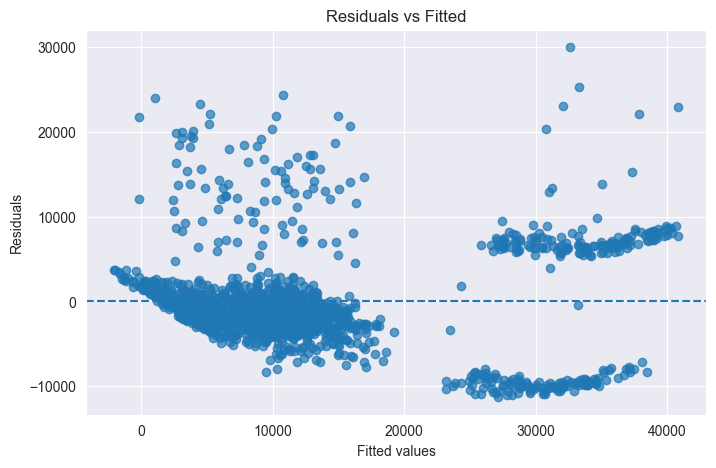

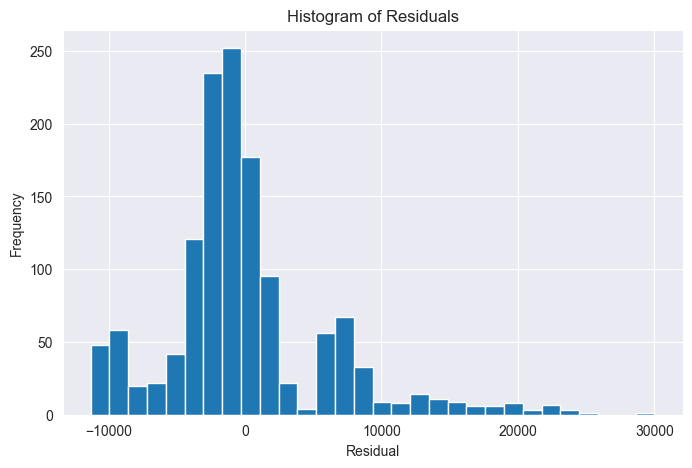

In [62]:

# Residuals and Fitted values
residuals = full_model.resid
fitted = full_model.fittedvalues

# Scatter plot for residuals vs Fitted values

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Histogram of residuals
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()



#### Interpretations:
* Non-linearity as bands points around zero in the plot
* Residuals are not normally distributed, they are left skewed and have outliers 

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [63]:
print("\n Significant Preditors:")
full_model.pvalues[(full_model.pvalues < 0.05)]


 Significant Preditors:


const               5.579044e-32
age                 7.783217e-89
bmi                 6.498194e-31
children            5.769682e-04
smoker_yes          0.000000e+00
region_southeast    3.078174e-02
region_southwest    4.476493e-02
dtype: float64

In [64]:
print("\n Not significant Preditors:")
full_model.pvalues[(full_model.pvalues >= 0.05)]



 Not significant Preditors:


sex_male            0.693348
region_northwest    0.458769
dtype: float64

In [65]:
best_features = ['age', 'bmi', 'children', 'smoker_yes', 'region_southeast', 'region_southwest']

X_best = sm.add_constant(X[best_features])
best_model = sm.OLS(y, X_best).fit()

print("\nBest Model Summary:", best_model.summary())

print('\n **** Full Model AIC - {}'.format(full_model.aic))
print('\n **** Best Model AIC - {}'.format(best_model.aic))



Best Model Summary:                             OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     668.3
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        08:10:22   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1331   BIC:                         2.715e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1

### Interpretations:
* For the above full model summary, these are the significant predictors ( p < 0.05 ) -
  * `age`, `bmi`, `children`, `smoker_yes`, `region_southeast`, `region_southwest`
* The AIC value for the ***best model*** is lower than the ***full model*** which indicates it is performing better.
* The ***best model*** does not include predictors such as `sex_male`, `region_northwest` compared to ***full model***
    



EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [66]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

In [67]:
import numpy as np

# Helper fuction for confusion matrix
def generate_confusion_matrix(cf, accuracy, title):
    group_labels = ["{}\n".format(value) for value in ['True Negative','False Positive','False Negative','True Positive']]
    group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    
    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])

    plt.figure(figsize=(5,5))
       
    sns.heatmap(cf,annot=box_labels, 
                linewidths=.4, 
                fmt="",
                cmap="Blues")
    
    plt.ylabel('True label')
   
    if accuracy:
        stats_text = "\n\n * Accuracy={:0.3f} *".format(accuracy)
        plt.xlabel('Predicted label' + stats_text)
    else:
         plt.xlabel('Predicted label')
    
    if title:
        plt.title(title)

    plt.show()

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [68]:
url = location + dataframe

col_names = [ 'Sample_code_number', 
             'Clump_thickness', 
             'Uniformity_of_cell_size',
             'Uniformity_of_cell_shape',
             'Marginal_adhesion',
             'Single_epithelial_cell_size',
             'Bare_nuclei',
             'Bland_chromatin',
             'Normal_nucleoli',
             'Mitoses',
             'Class' ]
df = pd.read_csv(url, header=None, names=col_names)

print("\nData types:", df.dtypes)
print("\nData shape:", df.shape)

# Identify the data to be replaced
print("\nUnique values for Bare_nuclei variable", df['Bare_nuclei'].unique())

# Replace incorrect values to NA
df = df.replace("?", pd.NA)

# Count of missing values per column
missing_count = df.isna().sum()

# Percentage of missing values per column
missing_percent = (missing_count / len(df)) * 100

# Combine into a single table
missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percent": missing_percent.round(2)
})
missing_summary

# Preserving original data set before dropping the NA rows
df_copy = df.copy()
df_copy = df_copy.dropna(subset=['Bare_nuclei'])
# Convert Bare_nuclei to integer
df_copy['Bare_nuclei'] = df_copy['Bare_nuclei'].astype(int)

print("\nData shape (After Clenaup):", df_copy.shape)


Data types: Sample_code_number              int64
Clump_thickness                 int64
Uniformity_of_cell_size         int64
Uniformity_of_cell_shape        int64
Marginal_adhesion               int64
Single_epithelial_cell_size     int64
Bare_nuclei                    object
Bland_chromatin                 int64
Normal_nucleoli                 int64
Mitoses                         int64
Class                           int64
dtype: object

Data shape: (699, 11)

Unique values for Bare_nuclei variable ['1' '10' '2' '4' '3' '9' '7' '?' '5' '8' '6']

Data shape (After Clenaup): (683, 11)


#### Observations:
* Extracted the column names from the UCI documentation and added appropriately to dataframe while reading the data.
* Shape of the data is **699** rows and **11** variables
* With respect to missing data, only `Bare_nuclei` has missing data. It accounts for 6 rows or approx. 2.29% of the entire data set which is significantly small and can be dropped without much impact.
* After cleanup, there are **683** rows 
  

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [69]:
from sklearn.model_selection import train_test_split

# Separate predictors and results
X = df_copy.drop(columns=['Class'])
y = df_copy['Class']

# Create train/test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,       # 30% test
    random_state=42,     
    stratify=y            
)

X_train.shape, X_test.shape


((478, 10), (205, 10))

#### Observations:
* Training data set has **478** rows
* Test data set has **205** rows

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

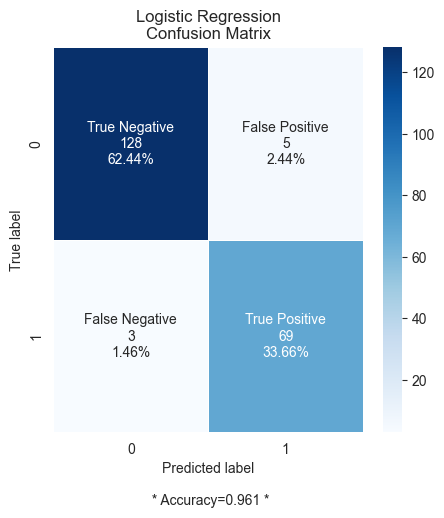

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
import seaborn as sns

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred)
acc_log = accuracy_score(y_test, y_pred)

# Generate confusion Matrix with accuracy score
generate_confusion_matrix(cm_log, acc_log, 'Logistic Regression\nConfusion Matrix')



#### Observations 

**Logistic Regression model** is selected for analysis as the target variable is binary in nature i.e. malignant or benign

##### Result interpretation based on confusion matrix
* True Positives -  69 rows (~33.66%) are correctly predicted as malignant
* True Negative - 128 rows (~62.44%) are correctly predicted as benign
* False Positive - 5 rows  (~2.44%) are incorrectly predicted as malignant and may cause anxiety among the patient, unnecessary additional tests & costs
* False Negative - 3 rows (~1.46%) are incorrectly predicted as benign. This is considered as most problematic as patients may not get timely treatment and possibly lead of life threatening situations

**Summary** - With respect medical context, I believe False Negatives are far more problematic than False Positives as it could become potentially life threatening situations if not addressed in timely manner.

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

#### Answers
Three real life applications for **classification** are -
   * Medical Diagnosis - Tumor Prediction
     * Predictors - `Tumor Size` ,`Cell Shape Uniformity`, `Cell Size Uniformity`, `Bare Nuclei` , `Mitoses`, `Clump Thickness`
     * Goal - Mostly prediction as it can classify unseen cases to support treatment or diagnosis. It can not provide inference on what cause the malignancy.
     * Response - Binary - Malignant or Benign
   * Credit Card Fraud Detection
     * Predictors - `Transaction Amount`,`Transaction Time`,`Transaction Geo Location`,`Customer Spending Pattern`, `Merchant Category`,`Transaction Device Details`
     * Goal - Mostly used to predict suspicious transaction and flag the transactions in real time.
     * Response - Binary - Fraudulent or Not Fraudulent
   * Email Spam Detection
     * Predictors - `Keywords in subject or body`, `Suspicious Link`, `Sender Address`, `Message Length`
     * Goal - Mostly used for classification of incoming messages into spam or not spam.
     * Response - Binary - Spam or Not Spam
    
  

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

#### Answers
Three real life applications for **regression** are -
   * Property Prices Prediction
     * Predictors - `Property Area`, `Features (Bedroom, Bathroom, Pool etc)`, `Property Location (Zip Code, School District, Flood zone)`, `Build Age`, `Demographics`
     * Goal - Mostly used for predicting estimated price of new property in the market
     * Response - Expected Market Price
   * Stock Price Prediction
     * Predictors - `Previous Closing prices`, `Trading volumes`, `Market Indexes`, `Financial Data (earnings, book value, market cap, outstanding shares )`, `Economic Indicators`, `Sentiment Indicator`
     * Goal - This could be used for forecast price estimates for stock
     * Response - Expected Stock Price
   * Predicting Medical Costs of Patients
     * Predictors - `Age`, `BMI`, `Gender`, `Smoking Status`, `Medical History`
     * Goal - Mostly able to estimate expected health cost for plan pricing
     * Response - Expected Medical Costs
                      

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

#### Interpretation

Advantages of a highly flexible regression or classification approach:

* Can capture complex and non-linear relationships in the data.

* Produces models with lower bias and generally better fit.

Disadvantages of a highly flexible regression or classification approach:

* Requires estimating a larger number of parameters.

* More likely to overfit by capturing noise rather than true patterns.

* Leads to higher variance and less stability in predictions.

When to choose which approach:

* A more flexible method is preferred when the goal is prediction accuracy rather than interpretability.

* A less flexible method is preferred when the goal is inference and interpretability, allowing clearer understanding of the   relationships between predictors and the response.

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

**Answer**

Normally the Least Square Function is represented as - $\hat{y} = \hat{\beta}_0 +  \hat{\beta}_1{X1} +  \hat{\beta}_2{X2} +  \hat{\beta}_3{X3} +  \hat{\beta}_4{X1}{X2} +  \hat{\beta}_5{X1}{X3}$

Here is the Least Square function for this problem

$\hat{y} = 50 +  20 * {GPA} +  0.07 * {IQ} +  35 * {Gender} +  0.01 * {GPA} * {IQ} - 10 * {GPA} * {Gender}$

Predicted Salary for Male (Gender = 0):

$\hat{y}~male = 50 +  20 * {GPA} +  0.07 * {IQ} + 0.01 * {GPA} * {IQ} $

Predicted Salary for Male (Female = 1):

$\hat{y}~female = 85 +  10 * {GPA} +  0.07 * {IQ} +  0.01 * {GPA} * {IQ}$

Difference between predicted salaries:

$\hat{y}~female - \hat{y}~male = 35 - 10 *  {GPA}$

Now based on the above difference, if GPA is less than 3.5 then females earn more than males. However with higher GPA than 3.5 males earn more than females.

Hence, the correct option is **(iii) - For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.**


(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

**Answer** 

Normally the Least Square Function is represented as - $\hat{y} = \hat{\beta}_0 +  \hat{\beta}_1{X1} +  \hat{\beta}_2{X2} +  \hat{\beta}_3{X3} +  \hat{\beta}_4{X1}{X2} +  \hat{\beta}_5{X1}{X3}$

Here is the Least Square function for this problem

$\hat{y} = 50 +  20 * {GPA} +  0.07 * {IQ} +  35 * {Gender} +  0.01 * {GPA} * {IQ} - 10 * {GPA} * {Gender}$

Below is the code to calculate the details -

In [71]:
GPA = 4
IQ = 110
Gender = 1 

predicted_salary = ( 50 + 20 * GPA + 0.07 * IQ + 35 * Gender + 0.01 * GPA * IQ - 10 * GPA * Gender ) * 1000
print("\nPredicted Salary for Female with GPA={} and IQ={} is ${}".format(GPA,IQ,predicted_salary))


Predicted Salary for Female with GPA=4 and IQ=110 is $137100.0


(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

**Answer**

**False** - Small coefficient does not mean that there is little interaction effect. GPA ranges from 0 - 4 and IQ ranges from 19 - 140. The product GPA * IQ will be large, even a small co-efficient multiplied with large interaction will have significant impact.


### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  

###### References

JMP. (n.d.). Regression model assumptions — What is regression? Statistics Knowledge Portal. https://www.jmp.com/en/statistics-knowledge-portal/what-is-regression/simple-linear-regression-assumptions

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in Python. Springer.
